# Исследовательский анализ сервиса Яндекс Афиша

- Автор: Свечникова Дарья Алексеевна
- Дата: 05.04.2026

**Введение**
Проект направлен на анализ данных сервиса Яндекс Афиша за период с 01.06.2024 по 31.10.2024.

**Цель исследования**
Провести анализ данных для выявления паттернов пользовательского поведения, сезонных изменений и формирования рекомендаций по развитию продукта.

**Основные задачи исследования**
- Анализ данных о заказах и мероприятиях
- Изучение сезонности и поведения пользователей
- Оценка региональной активности
- Проверка статистических гипотез
- Формирование выводов и рекомендаций

**Используемые данные**
- Данные о заказах билетов
- Информация о мероприятиях
- Курсы валют

---

## Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в трех переменных: `orders_df`, `events_df` и `tenge_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# # Импортируем функцию для теста Манна — Уитни
from scipy.stats import mannwhitneyu

In [2]:
# Выгружаем данные в переменные orders_df, events_df и tenge_df
orders_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
events_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

Познакомимся с данными датасета `orders_df` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
orders_df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
# Выводим информацию о датафрейме
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Датасет `orders_df` содержит 14 столбцов и 290 849 строк, в которых представлена информация о заказах билетов на сервисе Яндекс Афиша.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов соответствуют описанию.
- В столбце `days_since_prev` обнаружены пропущенные значения (21 940 строк) — это ожидаемо, так как у первых заказов пользователей нет предыдущей покупки.
- Типы данных в целом соответствуют содержимому, но можно оптимизировать:
    - `created_dt_msk` и `created_ts_msk` — необходимо перевести в формат **datetime** для работы с датами.
    - `device_type_canonical`, `currency_code`, `service_name` — можно перевести в тип **category**, так как содержат ограниченный набор значений.
    - `revenue`, `total`, `days_since_prev` — можно перевести в **float32** для экономии памяти.
- В датасете присутствуют две валюты: `rub` и `kzt` — необходимо привести к одной валюте (рублю).
- Столбец `revenue` содержит выручку с заказа, `tickets_count` — количество билетов, что позволит рассчитать выручку на один билет.

Теперь познакомимся с данными датасета `events_df`.

In [5]:
# Выводим первые строки датафрейма на экран
events_df.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
# Выводим информацию о датафрейме
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Датасет `events_df` содержит 11 столбцов и 22 427 строк, в которых представлена информация о мероприятиях, регионах, городах и площадках.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов соответствуют описанию.
- В столбцах отсутствуют пропуски, что говорит о хорошей заполненности данных.
- Типы данных:
  - `event_type_main`, `region_name`, `city_name`, `venue_name` — можно перевести в тип **category** для оптимизации.
  - `event_name` — строковый идентификатор, не подлежит оптимизации.
- Фильмы исключены, как указано в описании — подтверждается отсутствием значения `film` в `event_type_main`.
- Данные о событиях связаны с заказами через `event_id` — необходимо будет объединить датасеты.

Теперь познакомимся с данными датасета `tenge_df`.

In [7]:
# Выводим первые строки датафрейма на экран
tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
# Выводим информацию о датафрейме
tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Датасет `tenge_df` содержит 4 столбца и 357 строк, в которых представлена информация о курсе тенге к рублю за 2024 год.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов соответствуют описанию.
- Все значения заполнены, пропусков нет.
- Типы данных:
  - `data` — необходимо перевести в формат **datetime**.
  - `curs` — можно перевести в **float32**.
- Данные содержат курс за 100 тенге, что необходимо учитывать при конвертации.

Для дальнейшего анализа датасеты `orders_df` и `events_df` объединяются по столбцу `event_id`, который присутствует в обоих файлах. Выполнен **inner join**, чтобы сохранить только те заказы из `orders_df`, для которых есть информация о событиях в `events_df`. Это позволяет исключить заказы, не связанные с известными мероприятиями, и обеспечивает полноту данных для анализа.

In [9]:
# Объединим данные двух датасетов в один по столбцу event_id
df = orders_df.merge(events_df, on='event_id', how='inner')

In [10]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290611 non-null  int64  
 1   user_id                 290611 non-null  object 
 2   created_dt_msk          290611 non-null  object 
 3   created_ts_msk          290611 non-null  object 
 4   event_id                290611 non-null  int64  
 5   cinema_circuit          290611 non-null  object 
 6   age_limit               290611 non-null  int64  
 7   currency_code           290611 non-null  object 
 8   device_type_canonical   290611 non-null  object 
 9   revenue                 290611 non-null  float64
 10  service_name            290611 non-null  object 
 11  tickets_count           290611 non-null  int64  
 12  total                   290611 non-null  float64
 13  days_since_prev         268698 non-null  float64
 14  event_name          

In [11]:
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy() 
len(temp)

290611

---

## Предобработка данных
### Проверка данных на пропуски
Для начала проверим, есть ли пропуски в объединённом датасете `df`, кроме ожидаемого столбца `days_since_prev`.

In [12]:
# Применяем метод isna() к датафрейму df
print('Количество пропусков в каждом столбце:')
df.isna().sum()

Количество пропусков в каждом столбце:


order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21913
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
dtype: int64

- Пропуски обнаружены только в `days_since_prev`, что соответствует ожиданиям.
- Нет других пропусков, что подтверждает корректность выгрузки и согласованность данных.

---

### Изучение значений в ключевых столбцах и обработка ошибок
Теперь изучим значения в ключевых столбцах, чтобы:
- Проверить, есть ли ошибки (например, неожиданные категории, некорректные числа),
- Нормализовать данные, если нужно (например, привести категории к единому формату),
- Проверить, есть ли «пустые» или «заглушечные» значения, которые могут быть ошибкой.
#### Анализ категориальных значений
Проверим, какие категории присутствуют в данных, и встретятся ли значения, обозначающие пропуски или отсутствие информации.

In [13]:
# Уникальные значения в ключевых категориальных столбцах
print("Уникальные значения в device_type_canonical:")
print(df['device_type_canonical'].value_counts(dropna=False))

print("\nУникальные значения в currency_code:")
print(df['currency_code'].value_counts(dropna=False))

print("\nУникальные значения в event_type_main:")
print(df['event_type_main'].value_counts(dropna=False))

print("\nУникальные значения в age_limit:")
print(df['age_limit'].value_counts(dropna=False))

Уникальные значения в device_type_canonical:
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

Уникальные значения в currency_code:
rub    285542
kzt      5069
Name: currency_code, dtype: int64

Уникальные значения в event_type_main:
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

Уникальные значения в age_limit:
16    78556
12    62474
0     61487
6     52161
18    35933
Name: age_limit, dtype: int64


- Все категории корректны.
- `age_limit`: значения 0, 6, 12, 16, 18 — стандартные возрастные ограничения.
- Пропусков нет, заглушек (`'-', 'nan', ' '`) не обнаружено.
- Нормализация не требуется.

#### Анализ количественных значений
Теперь проверим распределение и наличие выбросов в `revenue` и `tickets_count`, разделив анализ по валютам (`rub`, `kzt`).

Начнем с `revenue` — RUB.

In [14]:
df_rub = df[df['currency_code'] == 'rub']
print("Статистика по revenue (RUB):")
print(df_rub['revenue'].describe())

Статистика по revenue (RUB):
count    285542.000000
mean        548.013929
std         871.750181
min         -90.760000
25%         114.170000
50%         346.630000
75%         793.320000
max       81174.540000
Name: revenue, dtype: float64


Средняя выручка на заказ — 548 руб, но медиана (346.63 руб) значительно ниже, а стандартное отклонение высокое (871.75 руб). Это указывает на сильное правоскошенное распределение: большая часть заказов — дешёвые, но есть небольшое число очень дорогих заказов (до 81 174 руб), которые «тянут» среднее вверх.

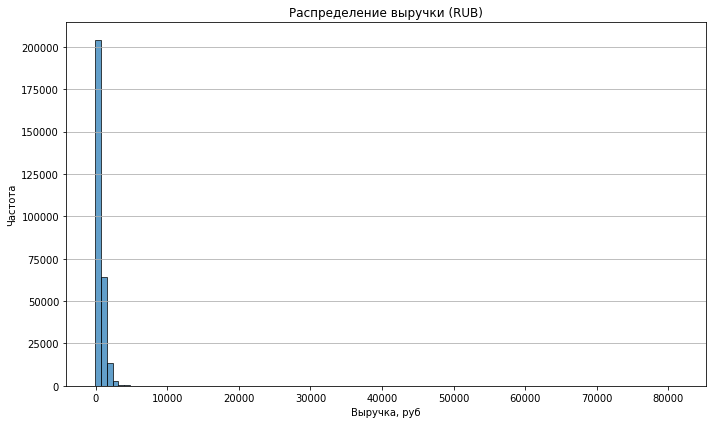

In [15]:
plt.figure(figsize=(10, 6))
df_rub['revenue'].hist(bins=100, edgecolor='black', alpha=0.7)
plt.title('Распределение выручки (RUB)')
plt.xlabel('Выручка, руб')
plt.ylabel('Частота')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

Гистограмма подтверждает правоскошенность: пик приходится на диапазон 100–500 руб, затем резкое падение частоты. Длинный «хвост» справа — это заказы на тысячи и десятки тысяч рублей, вероятно, пакетные билеты или премиум-события. Такие заказы редки, но существенны для общей выручки.

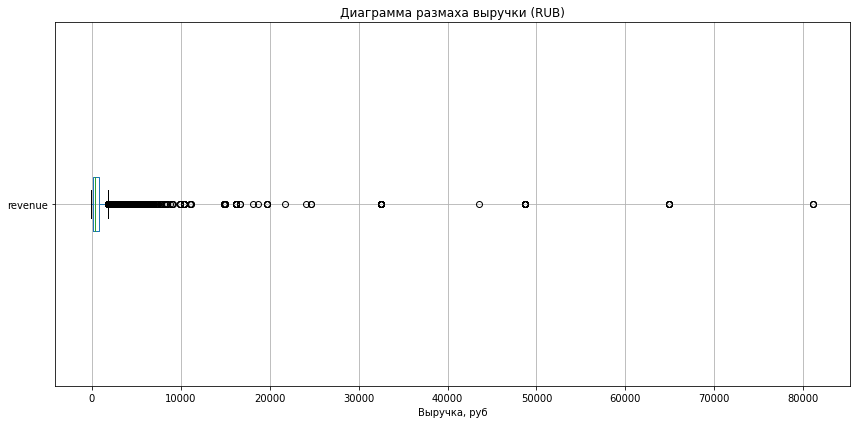

In [16]:
plt.figure(figsize=(12, 6))
df_rub.boxplot(column='revenue', vert=False)
plt.title('Диаграмма размаха выручки (RUB)')
plt.xlabel('Выручка, руб')
plt.grid(True)
plt.tight_layout()
plt.show()

На диаграмме видны многочисленные выбросы за пределами «усов» — это заказы выше 2500 руб. Межквартильный размах узок (от 114 до 793 руб), что говорит о том, что основная масса заказов сосредоточена в узком ценовом диапазоне, а выбросы — исключения. Для анализа сезонности и поведения пользователей такие экстремальные значения лучше исключить, чтобы не искажать тренды.

Теперь проверим распределение и наличие выбросов в `revenue` — KZT.

In [17]:
df_kzt = df[df['currency_code'] == 'kzt']
print("Статистика по revenue (KZT):")
print(df_kzt['revenue'].describe())

Статистика по revenue (KZT):
count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64


Средняя выручка в тенге — 4995 тнг, медиана — 3699 тнг, стандартное отклонение почти равно среднему — это признак сильной вариативности. Распределение также правоскошенное, но масштаб выше: максимальный заказ — 26 425 тнг, что соответствует премиум-событиям.

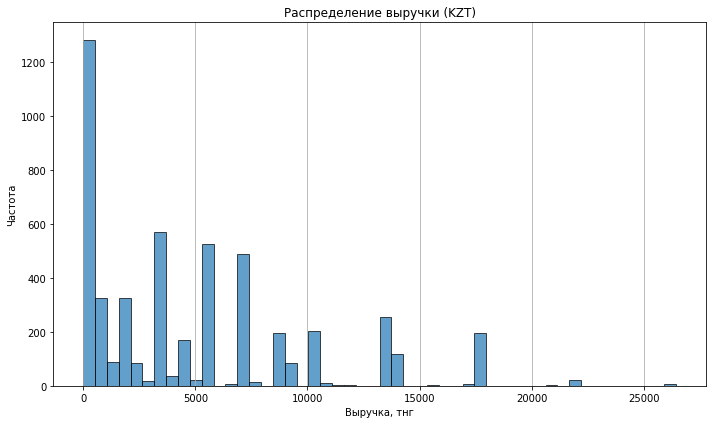

In [18]:
plt.figure(figsize=(10, 6))
df_kzt['revenue'].hist(bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение выручки (KZT)')
plt.xlabel('Выручка, тнг')
plt.ylabel('Частота')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Пик — в районе 0–5000 тнг, затем спад. Распределение менее «сжатое», чем в RUB, но общая картина аналогична: множество дешёвых заказов + редкие дорогие.

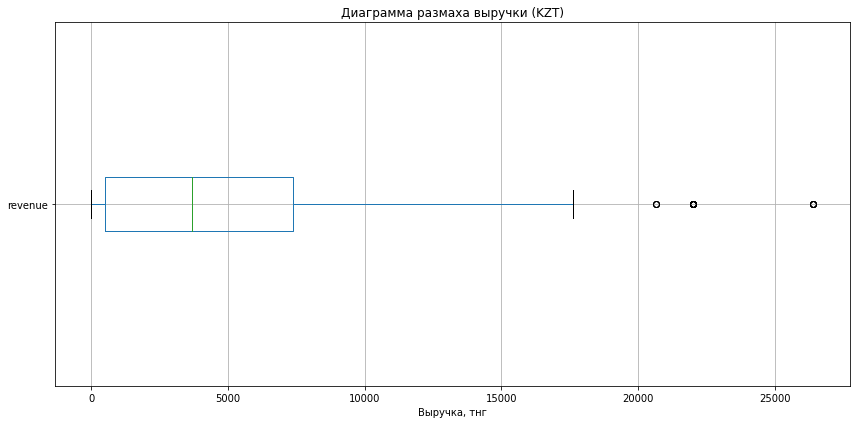

In [19]:
plt.figure(figsize=(12, 6))
df_kzt.boxplot(column='revenue', vert=False)
plt.title('Диаграмма размаха выручки (KZT)')
plt.xlabel('Выручка, тнг')
plt.grid(True)
plt.tight_layout()
plt.show()

Выбросы явно выражены: точки за пределами усов — это заказы свыше ~17 600 тнг (99-й процентиль). Они составляют <1% от выборки, но сильно влияют на среднее. Для стабильного анализа их целесообразно отфильтровать.

Теперь рассмотрим количество билетов в заказе `tickets_count`.

In [20]:
print("Статистика по tickets_count (RUB):")
print(df_rub['tickets_count'].describe())

Статистика по tickets_count (RUB):
count    285542.000000
mean          2.754159
std           1.171575
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


Среднее количество билетов — 2.75, медиана — 3, 75% заказов — до 4 билетов. Максимум = 57 это аномалия (возможно, корпоративный заказ или ошибка ввода), но она не влияет на общий тренд.

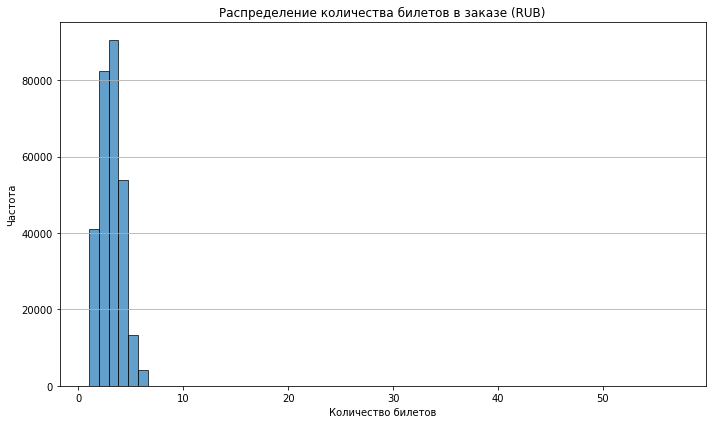

In [21]:
plt.figure(figsize=(10, 6))
df_rub['tickets_count'].hist(bins=60, edgecolor='black', alpha=0.7)
plt.title('Распределение количества билетов в заказе (RUB)')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

Явный пик на 3 билета, второй — на 2 и 4. Заказы на 1 билет — тоже распространены. Это говорит о том, что пользователи чаще покупают по 2–4 билета — например, для семьи или друзей. Заказы на 5+ билетов редки, но существуют.

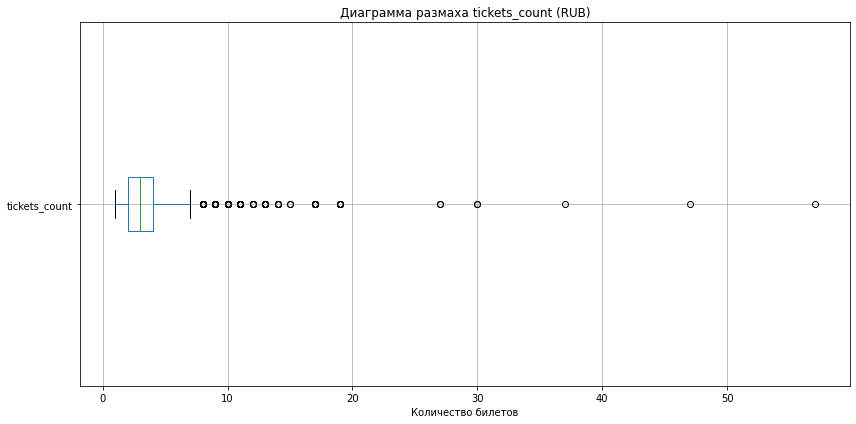

In [22]:
plt.figure(figsize=(12, 6))
df_rub.boxplot(column='tickets_count', vert=False)
plt.title('Диаграмма размаха tickets_count (RUB)')
plt.xlabel('Количество билетов')
plt.grid(True)
plt.tight_layout()
plt.show()

Усы охватывают диапазон 1–4 билета, выбросы — от 7 до 57. Поскольку таких заказов мало (<0.1%), они не требуют фильтрации — их можно оставить для анализа премиум-сегмента.

Рассмотрим `tickets_count` — тенге.

In [23]:
print("Статистика по tickets_count (KZT):")
print(df_kzt['tickets_count'].describe())

Статистика по tickets_count (KZT):
count    5069.000000
mean        2.762872
std         1.115558
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: tickets_count, dtype: float64


- Распределение почти идентично RUB, максимум — без аномалий.
- Фильтрация не требуется.

Теперь проверим остальные количественные столбцы.

In [24]:
# Проверка на логические ошибки в количественных столбцах
print("Проверка логических ошибок:")
print(f"Количество заказов с tickets_count < 1: {df[df['tickets_count'] < 1].shape[0]}")
print(f"Количество заказов с total < revenue: {df[df['total'] < df['revenue']].shape[0]}")
print(f"Количество заказов с days_since_prev < 0: {df[df['days_since_prev'] < 0].shape[0]}")

Проверка логических ошибок:
Количество заказов с tickets_count < 1: 0
Количество заказов с total < revenue: 383
Количество заказов с days_since_prev < 0: 0


In [25]:
# Проверим, какие значения revenue и total в строках, где total < revenue
anomaly = df[df['total'] < df['revenue']]
print(anomaly[['revenue', 'total']].head(10))

       revenue  total
24218    -2.37 -59.20
24219    -1.58 -39.46
24220    -1.58 -39.46
24221    -2.37 -59.20
24222    -1.58 -39.46
24223    -2.37 -59.20
24224    -2.37 -59.20
24225    -2.37 -59.20
24226    -0.79 -19.73
24227    -2.37 -59.20


- Обнаружено 383 заказа, где `total` < `revenue`.
- Анализ показал, что все такие заказы имеют отрицательные значения как в `revenue`, так и в `total`.
- Значит это возвраты билетов, а не ошибки в данных.
- Удалять их не будем, так как они отражают реальные действия пользователей и не искажают метрики.

**Фильтрация по 99-му процентилю**

Найдем 99-й процентиль по `revenue` для каждой валюты и отфильтруем выбросы.

In [26]:
# 99-й процентиль по валютам
perc_99_rub = df_rub['revenue'].quantile(0.99)
perc_99_kzt = df_kzt['revenue'].quantile(0.99)

print(f'99-й процентиль выручки (RUB): {perc_99_rub}')
print(f'99-й процентиль выручки (KZT): {perc_99_kzt}')

# Фильтрация
df = df[
    ((df['currency_code'] == 'rub') & (df['revenue'] <= perc_99_rub)) |
    ((df['currency_code'] == 'kzt') & (df['revenue'] <= perc_99_kzt))]

print(f'\nРазмер датасета после фильтрации: {df.shape}')

99-й процентиль выручки (RUB): 2570.8
99-й процентиль выручки (KZT): 17617.24

Размер датасета после фильтрации: (287782, 24)


---

### Проверка явных и неявных дубликатов в данных

In [27]:
# Проверяем явные дубликаты в датафрейме df
print("Количество явных дубликатов:", df.duplicated().sum())

Количество явных дубликатов: 0


Теперь проверим неявные дубликаты.

In [28]:
# Проверим неявные дубликаты по более точным признакам: с учётом времени заказа
subset_cols_updated = ['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue']

# Находим строки, которые дублируются по этим признакам
duplicates_updated = df[df.duplicated(subset=subset_cols_updated, keep=False)]

print(f"Количество неявных дубликатов по точному времени: {len(duplicates_updated)}")

if len(duplicates_updated) > 0:
    duplicates_updated = duplicates_updated.sort_values(by=['user_id', 'event_id'])
    print("\nПримеры неявных дубликатов (по точному времени):")
    display(duplicates_updated[['order_id', 'user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue']])
else:
    print("Неявных дубликатов по точному времени не найдено.")

Количество неявных дубликатов по точному времени: 83

Примеры неявных дубликатов (по точному времени):


,order_id,user_id,event_id,created_ts_msk,tickets_count,revenue
184947,1123983,06eb7897f65b433,183706,2024-08-13 16:31:07,1,69.82
184948,1123867,06eb7897f65b433,183706,2024-08-13 16:31:07,1,69.82
151803,5593202,08199117318954f,553623,2024-07-31 11:52:06,3,0.00
151804,5592970,08199117318954f,553623,2024-07-31 11:52:06,3,0.00
126876,1930705,0dc525d7bacbb0d,393430,2024-07-31 13:26:11,3,1556.05
...,...,...,...,...,...,...
178429,8548012,fd4d47438ebb946,489843,2024-06-19 15:40:56,4,1319.43
178431,8548041,fd4d47438ebb946,489843,2024-06-19 15:40:50,3,989.57
178432,8548070,fd4d47438ebb946,489843,2024-06-19 15:40:50,3,989.57
178433,8548099,fd4d47438ebb946,489843,2024-06-19 15:40:56,3,989.57


- Найдено 83 неявных дубликата по точному времени заказа.
- Эти строки полностью совпадают по параметрам: `user_id`, `event_id`, `created_ts_msk`, `tickets_count`, `revenue`.
- Решение: удалить дубликаты, оставляя по одной строке из каждой группы, чтобы не искажать метрики.

In [29]:
# Сколько строк было до удаления дубликатов
rows_before = df.shape[0]

# Удаляем дубликаты
df = df.drop_duplicates(subset=['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue'])

# Сколько стало после
rows_after = df.shape[0]

print(f"Удалено строк: {rows_before - rows_after}")

Удалено строк: 43


После удаления дубликатов (оставляя по одной строке из каждой группы) — удалено 43 строки.

---

### Преобразуем типы данных
Для оптимизации будем использовать методы:
- pd.to_datetime() — для преобразования столбцов `created_dt_msk`, `created_ts_msk`, `data` в формат даты.
- astype('category') — для оптимизации категориальных столбцов `device_type_canonical`, `currency_code`, `service_name`, `event_type_main`, `region_name`, `city_name`, `venue_name`.
- pd.to_numeric(..., downcast='float') — для оптимизации типов столбцов `revenue`, `total`, `days_since_prev`, `curs` в **float32**.

In [30]:
# Преобразование типов данных

# Даты
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

# Категории
category_cols = [
    'device_type_canonical', 'currency_code', 'service_name',
    'event_type_main', 'region_name', 'city_name', 'venue_name'
]
for col in category_cols:
    df[col] = df[col].astype('category')

# Оптимизация числовых типов
df['revenue'] = pd.to_numeric(df['revenue'], downcast='float')
df['total'] = pd.to_numeric(df['total'], downcast='float')
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='float')
tenge_df['curs'] = pd.to_numeric(tenge_df['curs'], downcast='float')

print("Типы данных после преобразований:")
print(df.dtypes)
print(tenge_df.dtypes)

Типы данных после преобразований:
order_id                           int64
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int64
cinema_circuit                    object
age_limit                          int64
currency_code                   category
device_type_canonical           category
revenue                          float32
service_name                    category
tickets_count                      int64
total                            float32
days_since_prev                  float32
event_name                        object
event_type_description            object
event_type_main                 category
organizers                        object
region_name                     category
city_name                       category
city_id                            int64
venue_id                           int64
venue_name                      category
venue_address          

Типы данных преобразованы:
  - Даты: `created_dt_msk`, `created_ts_msk`, `data` — **`datetime64[ns]`**.
  - Категории: `device_type_canonical`, `currency_code`, `event_type_main`, `region_name`, `city_name`, `venue_name` — **`category`**.
  - Числа: `revenue`, `total`, `days_since_prev`, `curs` — **`float32`** (экономия памяти).

`tenge_df` — тоже обновлён, и пригоден для конвертации валюты.

---

### Создание новых столбцов
Создадим новые столбцы для дальнейшего анализа:
- `revenue_rub` — выручка в рублях (конвертация из тенге по курсу),
- `one_ticket_revenue_rub` — доход на один билет (в рублях),
- `month` — месяц заказа,
- `season` — сезон (лето, осень и т.д.).

In [31]:
# Сортируем tenge_df по дате и заполняем пропуски в курсе
tenge_df = tenge_df.sort_values(by='data').reset_index(drop=True)
tenge_df['curs'] = tenge_df['curs'].fillna(method='ffill')

# Теперь объединяем
df = df.merge(
    tenge_df[['data', 'curs']],
    left_on='created_dt_msk',
    right_on='data',
    how='left')

# Создаём revenue_rub
df['revenue_rub'] = df['revenue']
df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = (
    df.loc[df['currency_code'] == 'kzt', 'revenue'] * df.loc[df['currency_code'] == 'kzt', 'curs'] / 100)

# one_ticket_revenue_rub
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

# Месяц и сезон
df['month'] = df['created_dt_msk'].dt.month
df['season'] = df['month'].map({
    6: 'лето', 7: 'лето', 8: 'лето',
    9: 'осень', 10: 'осень', 11: 'осень',
    12: 'зима', 1: 'зима', 2: 'зима',
    3: 'весна', 4: 'весна', 5: 'весна'})

# Проверим результат
df[['revenue', 'currency_code', 'revenue_rub', 'one_ticket_revenue_rub', 'month', 'season']].head()

,revenue,currency_code,revenue_rub,one_ticket_revenue_rub,month,season
0,1521.939941,rub,1521.939941,380.484985,8,лето
1,1902.420044,rub,1902.420044,380.484009,7,лето
2,1141.449951,rub,1141.449951,380.483317,7,лето
3,1902.420044,rub,1902.420044,380.484009,7,лето
4,1521.939941,rub,1521.939941,380.484985,7,лето


In [32]:
# Сколько строк было до предобработки
print(f"{temp.shape[0]} строк было до предобработки")

# Сколько стало после
print(f"{df.shape[0]} строк стало после предобработки")

print(f"{temp.shape[0] - df.shape[0]} строк удалено")

290611 строк было до предобработки
287739 строк стало после предобработки
2872 строк удалено


После всех этапов предобработки:
- Исходный датасет (`temp`) — 290 611 строк.
- Финальный датасет (`df`) — 287 739 строк.
- Удалено 2 872 строки:
    - 2 829 — фильтрация по 99-му процентилю (выбросы в `revenue`).
    - 43 — неявные дубликаты.

Новые столбцы:
- `revenue_rub` — унифицированная выручка в рублях (включая конвертацию из тенге).
- `one_ticket_revenue_rub` — доход на один билет (в рублях).
- `month`, `season` — временные признаки, для анализа сезонности.

Типы данных — оптимизированы, память уменьшена, работа ускорена.

Данные готовы к исследовательскому анализу и проверке гипотез.

---

## Исследовательский анализ данных
### Анализ распределения заказов по сегментам и их сезонные изменения
В этом разделе мы:
- Изучим сезонные изменения в количестве заказов.
- Сравним распределение по типу мероприятия, устройству, возрастному рейтингу.
- Оценим изменение выручки на билет по типам мероприятий.
- Сделаем выводы о сезонности и изменениях в поведении пользователей.

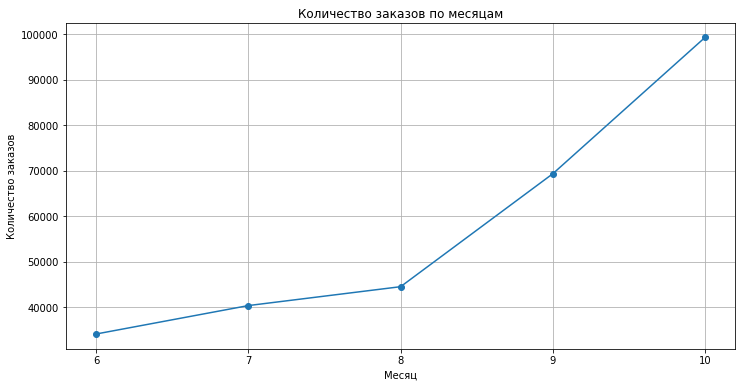

In [33]:
# Количество заказов по месяцам
df.groupby('month')['order_id'].count().plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.xticks(range(6, 11))
plt.grid(True)
plt.show()

Количество заказов растёт с июня по октябрь, при этом сентябрь–октябрь — резкий скачок. 
Это подтверждает сезонность: осенью пользовательская активность возрастает, возможно, из-за начала театрального сезона, подготовки к праздникам и возвращения с отпусков.

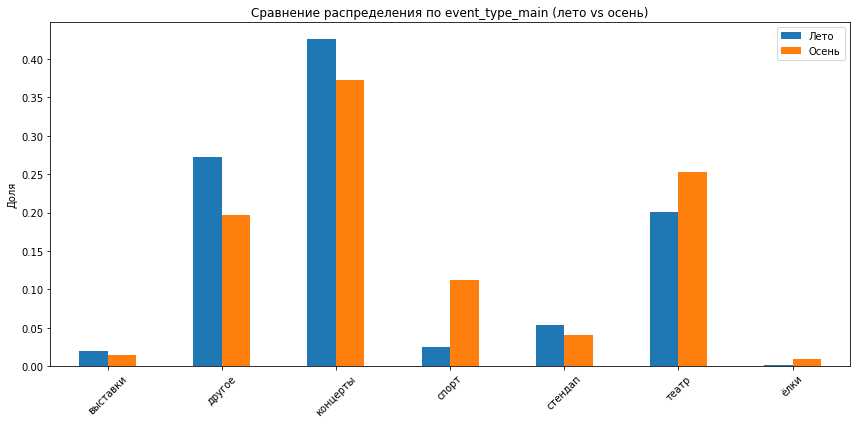

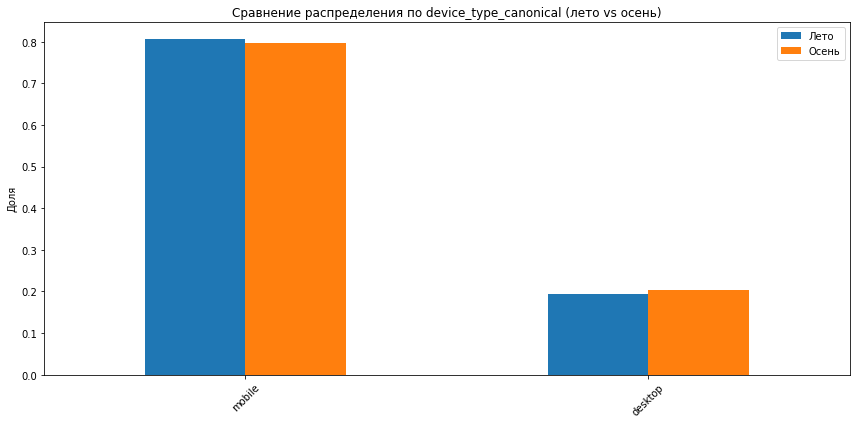

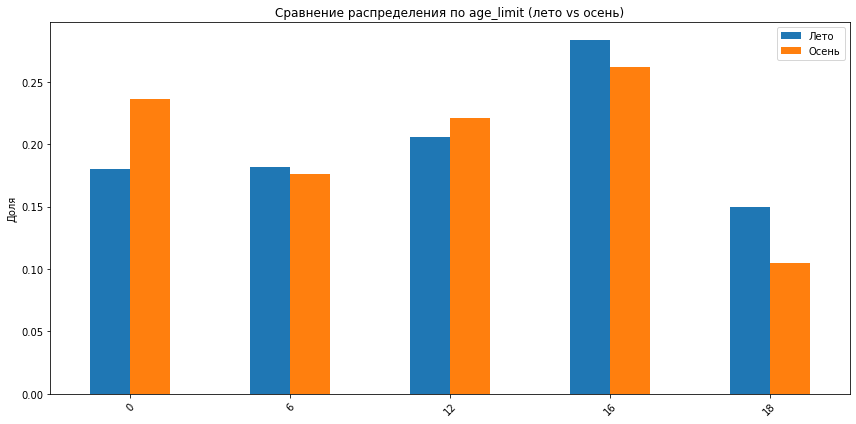

In [34]:
# Сегменты: event_type_main, device_type_canonical, age_limit
segments = ['event_type_main', 'device_type_canonical', 'age_limit']

for seg in segments:
    summer = df[df['season'] == 'лето'][seg].value_counts(normalize=True)
    autumn = df[df['season'] == 'осень'][seg].value_counts(normalize=True)
    
    comparison = pd.DataFrame({'Лето': summer, 'Осень': autumn})
    
    comparison.plot(kind='bar', figsize=(12, 6))
    plt.title(f'Сравнение распределения по {seg} (лето vs осень)')
    plt.ylabel('Доля')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

- `event_type_main`: С наступлением осени доля заказов на театральные постановки и спорт растёт, а на концерты и «другое» — снижается; появляются заказы на ёлки. Это указывает на структурный сдвиг спроса в сторону классических, спортивных и праздничных форматов осенью.
- `device_type_canonical`: Распределение заказов по типу устройства не меняется между летом и осенью: мобильные устройства сохраняют доминирующую долю (~80%), десктопы — стабильные ~20%. Сезонность не влияет на выбор платформы пользователей.
- `age_limit`: С наступлением осени доля заказов на мероприятия (0+) и с ограничением 12+ растёт, а доля мероприятий с ограничением 16+ и 18+ снижается. Это указывает на смещение спроса в сторону семейных и молодёжных событий осенью.

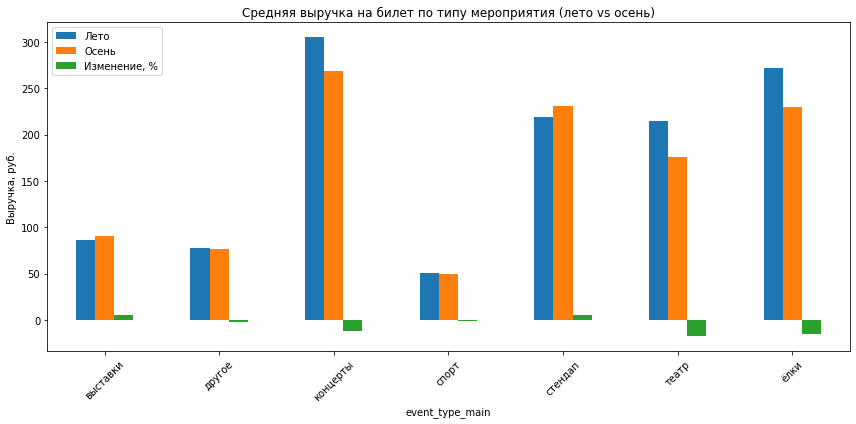

,Лето,Осень,"Изменение, %"
event_type_main,,,
выставки,86.416197,90.603609,4.845633
другое,77.439799,76.115333,-1.710316
концерты,304.785458,268.360658,-11.950964
спорт,50.761831,49.970896,-1.558130
стендап,218.518108,231.124973,5.769255
театр,214.138855,175.977088,-17.821038
ёлки,271.436177,229.585590,-15.418205


In [35]:
# Средняя выручка на билет по типу мероприятия
revenue_by_event_summer = df[df['season'] == 'лето'].groupby('event_type_main')['one_ticket_revenue_rub'].mean()
revenue_by_event_autumn = df[df['season'] == 'осень'].groupby('event_type_main')['one_ticket_revenue_rub'].mean()

comparison_revenue = pd.DataFrame({'Лето': revenue_by_event_summer, 'Осень': revenue_by_event_autumn})

comparison_revenue['Изменение, %'] = (
    (comparison_revenue['Осень'] - comparison_revenue['Лето']) / comparison_revenue['Лето'] * 100)

comparison_revenue.plot(kind='bar', figsize=(12, 6))
plt.title('Средняя выручка на билет по типу мероприятия (лето vs осень)')
plt.ylabel('Выручка, руб.')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

comparison_revenue

- Снижается средняя выручка на билет в театре (−17.8%), ёлках (−15.4%) и концертах (−11.9%).
- Растёт — у стендапа (+5.8%) и выставок (+4.8%).

Это указывает на дешевизну осенних мероприятий в ключевых категориях, что объясняет снижение среднего чека при росте числа заказов.

Распределение заказов по категориям:
- Тип устройства (`device_type_canonical`): не меняется — мобильные устройства сохраняют ~80% заказов.
- Возрастное ограничение (`age_limit`): растёт доля заказов на мероприятия без ограничений (0+) и 12+, снижается — 16+ и 18+ — смещение к семейным и молодёжным событиям.
- Тип мероприятия (`event_type_main`): растёт доля театра, спорта и ёлок, падает — концертов и «другого».

Средняя стоимость билета по типам мероприятий:
- Снижается в ключевых категориях: театр (−17.8%), ёлки (−15.4%), концерты (−11.9%).
- Растёт у стендапа (+5.8%) и выставок (+4.8%), но вклад в общую выручку — меньше.

С наступлением осени структура спроса смещается в сторону семейных, молодёжных и культурных мероприятий, при этом средняя стоимость билета падает по основным направлениям (театр, концерты, ёлки), что объясняет рост объёма заказов при снижении среднего чека.

---

### Осенняя активность пользователей
В этом разделе мы:
- Проанализируем динамику по дням (сентябрь–октябрь): число заказов, DAU, среднее число заказов на пользователя, среднюю стоимость билета;
- Построим линейные графики для визуализации тенденций;
- Исследуем недельную цикличность — сравним активность в будни и выходные.

In [36]:
# Фильтруем только осенние данные (сентябрь и октябрь)
df_autumn = df[df['season'] == 'осень'].copy()

In [37]:
# Агрегация по дням
daily = df_autumn.groupby('created_dt_msk').agg(
    orders=('order_id', 'count'),
    dau=('user_id', 'nunique')).reset_index()

# Добавляем расчётные метрики
daily['orders_per_user'] = daily['orders'] / daily['dau']
daily['avg_ticket_rev'] = df_autumn.groupby('created_dt_msk')['one_ticket_revenue_rub'].mean().values

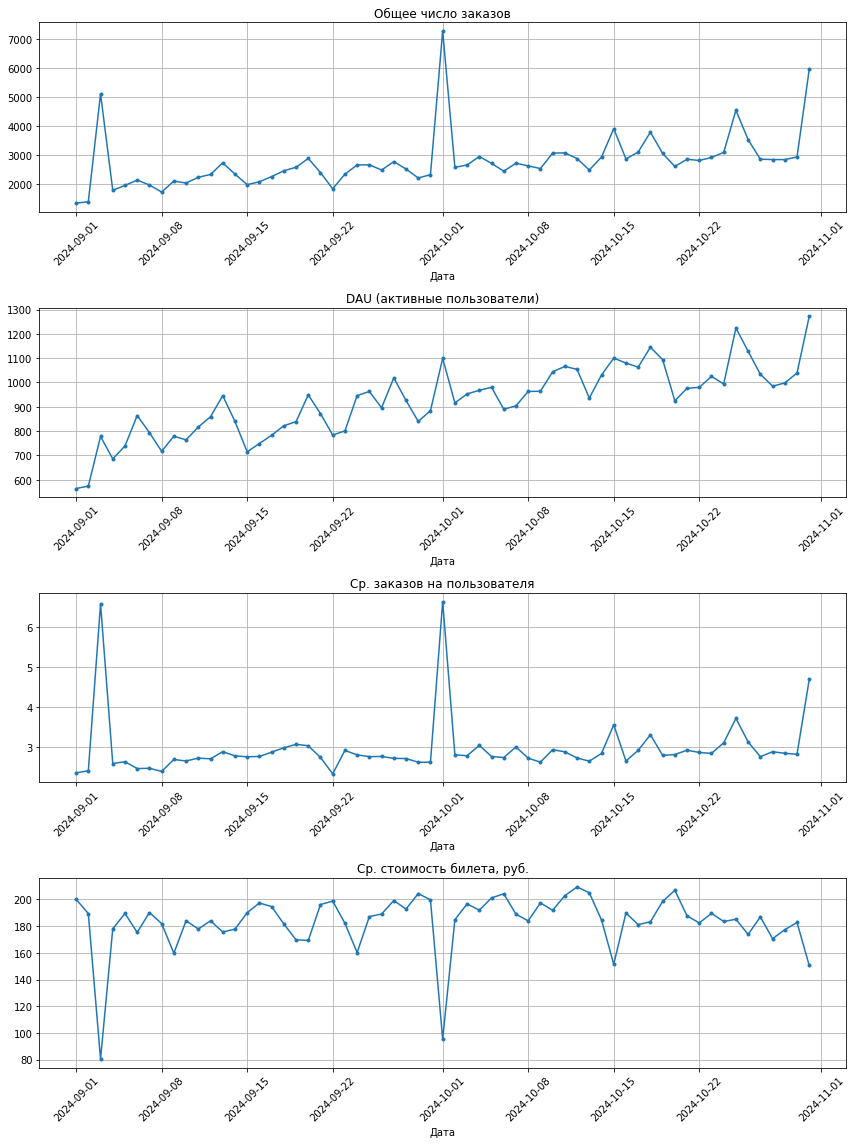

In [38]:
# Визуализация 
plt.figure(figsize=(12, 16))

metrics = [
    ('orders', 'Общее число заказов'),
    ('dau', 'DAU (активные пользователи)'),
    ('orders_per_user', 'Ср. заказов на пользователя'),
    ('avg_ticket_rev', 'Ср. стоимость билета, руб.')]

for i, (col, title) in enumerate(metrics, 1):
    plt.subplot(4, 1, i)
    plt.plot(daily['created_dt_msk'], daily[col], marker='o', markersize=3)
    plt.title(title)
    plt.xlabel('Дата')
    plt.xticks(rotation=45)
    plt.grid(True)

plt.tight_layout()
plt.show()

Графики показывают:
- Рост активности к концу октября (пик 31 октября — 6000 заказов),
- DAU растёт синхронно с заказами,
- Среднее число заказов на пользователя стабильно ~2.5–3.1,
- Средняя стоимость билета колеблется в диапазоне 150–200 руб, с пиками в выходные.

In [39]:
# Добавляем день недели: 0–4 — будни, 5–6 — выходные
daily['weekday'] = daily['created_dt_msk'].dt.weekday
daily['is_weekend'] = daily['weekday'] >= 5  # True — сб/вс

# Средние метрики по будням и выходным
summary = daily.groupby('is_weekend').agg(
    orders_mean=('orders', 'mean'),
    dau_mean=('dau', 'mean'),
    orders_per_user_mean=('orders_per_user', 'mean'),
    ticket_rev_mean=('avg_ticket_rev', 'mean')).round(2)

print("Средние метрики:")
summary

Средние метрики:


,orders_mean,dau_mean,orders_per_user_mean,ticket_rev_mean
is_weekend,,,,
False,2906.61,937.41,3.07,178.61
True,2396.00,887.82,2.68,195.22


Осенью наблюдается устойчивая недельная цикличность:
- Будни — доминируют по объёму: выше количество заказов и активных пользователей, а также среднее число заказов на человека (3.07 vs 2.68). Это указывает на плановую активность: пользователи бронируют билеты в течение недели (например, на выходные или на следующую неделю).
- Выходные — ниже объём, но выше средняя стоимость билета: пользователи выбирают более дорогие события (театр, концерты, премьеры), часто единичные покупки для себя или семьи.

---

### Популярные события и партнёры
В этом разделе мы:
- Определим топ-регионы по числу мероприятий и заказов;
- Выделим ключевых партнёров по числу мероприятий, заказов и выручке;
- Оценим доли лидеров в общем объеме (не только абсолютные значения);
- Сделаем промежуточный вывод о распределении активности между регионами и партнёрами.

In [40]:
# Считаем уникальные мероприятия и заказы по регионам
regional_summary = df.groupby('region_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'count')
).sort_values(by='events', ascending=False)

# Добавляем доли
regional_summary['events_share'] = (regional_summary['events'] / regional_summary['events'].sum()) * 100
regional_summary['orders_share'] = (regional_summary['orders'] / regional_summary['orders'].sum()) * 100

print("ТОП-10 регионов по заказам:")
regional_summary.head(10)

ТОП-10 регионов по заказам:


,events,orders,events_share,orders_share
region_name,,,,
Каменевский регион,5935,89660,26.544121,31.160183
Североярская область,3800,43738,16.995393,15.200581
Широковская область,1232,16169,5.510085,5.619329
Светополянский округ,1075,7501,4.807907,2.606876
Речиновская область,702,6266,3.139675,2.177668
Травяная область,683,5036,3.054698,1.750197
Горицветская область,551,5152,2.464332,1.790512
Серебринская область,541,5586,2.419607,1.941343
Яблоневская область,535,6123,2.392772,2.127970


In [41]:
# Считаем уникальные мероприятия, заказы и выручку по партнёрам
partner_summary = df.groupby('service_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'count'),
    revenue=('revenue_rub', 'sum')
).sort_values(by='revenue', ascending=False)

# Добавляем доли
partner_summary['events_share'] = (partner_summary['events'] / partner_summary['events'].sum()) * 100
partner_summary['orders_share'] = (partner_summary['orders'] / partner_summary['orders'].sum()) * 100
partner_summary['revenue_share'] = (partner_summary['revenue'] / partner_summary['revenue'].sum()) * 100

print("ТОП-10 партнёров по выручке:")
partner_summary.head(10)

ТОП-10 партнёров по выручке:


,events,orders,revenue,events_share,orders_share,revenue_share
service_name,,,,,,
Билеты без проблем,4247,62855,24322066.0,17.416445,21.844449,16.295614
Мой билет,1300,34438,22041902.0,5.331146,11.968485,14.767921
Облачко,2335,26402,18588614.0,9.575559,9.175677,12.454243
Лови билет!,4867,40800,16673854.0,19.958991,14.179517,11.171367
Весь в билетах,855,16424,16532347.0,3.506254,5.707951,11.076557
Билеты в руки,3530,40277,13193455.0,14.476112,13.997755,8.839523
Край билетов,252,6109,6405689.0,1.033422,2.123105,4.291767
Прачечная,1026,10222,4746810.5,4.207505,3.552525,3.180330
Дом культуры,272,4412,4358656.0,1.115440,1.533334,2.920269


Регионы:
- Каменевский регион — лидер по числу мероприятий (26.5% от общего числа), второй по числу заказов (31%).
- Североярская область — второе место по мероприятиям (17%) и первое по заказам (15%).
- Эти два региона — центр активности, суммарно обеспечивают 43% мероприятий и 46% заказов.
- Остальные регионы — рассредоточены, без явного доминирования.
- Возможная причина: географическая доступность, наличие культурных/спортивных объектов, насыщенность досугом, уровень дохода населения.
- Значение: фокусировать маркетинг и партнёрские программы на этих двух регионах, рассмотреть потенциал для расширения в ближайшие области.

Партнёры:
- ТОП-5 партнёров (Без проблем, Мой билет, Облачко, Лови билет!, Весь в билетах) — 70% выручки, 50% заказов, 52% мероприятий.
- ТОП-10 — почти 90% выручки, >70% заказов, 70% мероприятий.
- Остальные — низкая активность, малый вклад.
- Значительная концентрация активности в узком круге партнёров.
- Различие в рейтинге - Лови билет! — 1-е место по числу мероприятий (19.9%), но 4-е по выручке (11.2%).
    - Билеты без проблем — 1-е по выручке (16.3%), но 4-е по числу мероприятий (17.4%).
    - Это может говорить о разной стратегии (широта охвата vs. премиум-сегмент), эффективности продаж, ценовой политике.
- Аутсайдеры: Многие партнёры имеют низкую активность.
    - Однако, некоторые из них могут представлять потенциал для роста, особенно если они специализируются на нишевых сегментах или локальных рынках.

**Промежуточный вывод**
1. Сезонность и поведение пользователей:
- Рост активности осенью — четко выражен:
    - Количество заказов растёт с июня по октябрь, особенно резко в сентябре–октябре.
    - Это объясняется возвращением с отпусков, началом театрального сезона, подготовкой к праздникам.
- Изменение структуры спроса осенью:
    - Растёт доля мероприятий:
        - Театр, спорт, ёлки.
        - Семейные (0+) и молодёжные (12+) мероприятия.
    - Падает доля:
        - Концертов и «другого».
        - Мероприятий 16+ и 18+.
    - Средняя стоимость билета снижается в ключевых категориях (театр, ёлки, концерты), что указывает на демпинг или доступность, при этом объём заказов растёт.

2. Поведение пользователей осенью:
- Недельная цикличность выражена:
    - Будни: высокий объём заказов и DAU, среднее число заказов на пользователя выше (3.07 vs 2.68), ниже средняя стоимость билета.
        - Это плановая активность: пользователи бронируют заранее, для семьи/друзей.
    - Выходные: ниже объём, но выше средняя стоимость билета (195 руб vs 178 руб).
        - Это спонтанные, но более премиальные покупки: театр, концерты, премьеры.

3. Региональное и партнёрское распределение:
- Регионы:
    - Каменевский регион и Североярская область — центр активности:
        - 43% мероприятий, 46% заказов.
    - Остальные регионы — рассредоточены, мало активности.
- Партнёры:
    - ТОП-5 партнёров обеспечивают 70% выручки, 50% заказов и мероприятий.
    - ТОП-10 — почти 90% выручки.
    - Остальные — вспомогательные, нишевые.

---

## Статистический анализ данных
В этом разделе мы:
- Сформулируем нулевую и альтернативную гипотезы;
- Обоснуем выбор статистических тестов;
- Проверим две гипотезы, касающиеся поведения пользователей мобильных и стационарных устройств;
- Сделать выводы по результатам.

In [42]:
# Используем уже подготовленный df_autumn
# Считаем количество заказов на пользователя
user_orders = df_autumn.groupby(['user_id', 'device_type_canonical']).size().reset_index(name='order_count')

# Сортируем по пользователю и времени
df_sorted = df_autumn.sort_values(['user_id', 'created_ts_msk'])

# Добавляем предыдущую дату заказа
df_sorted['prev_time'] = df_sorted.groupby('user_id')['created_ts_msk'].shift(1)

# Считаем разницу в днях между заказами
df_sorted['time_diff'] = (df_sorted['created_ts_msk'] - df_sorted['prev_time']).dt.days

# Среднее время между заказами для каждого пользователя
time_diffs = df_sorted.groupby('user_id')['time_diff'].mean().reset_index(name='avg_time_diff')

# Объединяем с количеством заказов
user_data = user_orders.merge(time_diffs, on='user_id', how='inner')
# user_data = user_data.dropna()  # Убираем пользователей с 1 заказом
user_data = user_data[user_data['avg_time_diff'].notna()]  # Удаляем только NaN в avg_time_diff

In [43]:
mobile_orders = user_data[user_data['device_type_canonical'] == 'mobile']['order_count']
desktop_orders = user_data[user_data['device_type_canonical'] == 'desktop']['order_count']

# Проверяем, сколько пользователей в каждой группе
print(f'Количество мобильных пользователей: {len(mobile_orders)}')
print(f'Количество десктопных пользователей: {len(desktop_orders)}')

# Проверяем средние и медианы
print(f'Среднее кол-во заказов (mobile): {mobile_orders.mean():.2f}')
print(f'Среднее кол-во заказов (desktop): {desktop_orders.mean():.2f}')
print(f'Медиана кол-ва заказов (mobile): {mobile_orders.median()}')
print(f'Медиана кол-ва заказов (desktop): {desktop_orders.median()}')

mobile_time = user_data[user_data['device_type_canonical'] == 'mobile']['avg_time_diff']
desktop_time = user_data[user_data['device_type_canonical'] == 'desktop']['avg_time_diff']

# Проверяем средние и медианы
print(f'\nСреднее время между заказами (mobile): {mobile_time.mean():.2f} дней')
print(f'Среднее время между заказами (desktop): {desktop_time.mean():.2f} дней')
print(f'Медиана времени между заказами (mobile): {mobile_time.median():.2f}дней')
print(f'Медиана времени между заказами (desktop): {desktop_time.median():.2f} дней')

Количество мобильных пользователей: 9397
Количество десктопных пользователей: 9397
Среднее кол-во заказов (mobile): 13.72
Среднее кол-во заказов (desktop): 3.54
Медиана кол-ва заказов (mobile): 3.0
Медиана кол-ва заказов (desktop): 0.0

Среднее время между заказами (mobile): 6.04 дней
Среднее время между заказами (desktop): 6.04 дней
Медиана времени между заказами (mobile): 2.94дней
Медиана времени между заказами (desktop): 2.94 дней


- Сравниваем 2 группы: пользователи мобильных и десктопных устройств.
- Метрики:
    - Среднее количество заказов на пользователя.
    - Среднее время между заказами.
- Для проверки гипотезы выбран **односторонний тест Манна‑Уитни**, так как он подходит для сравнения двух независимых групп без предположения о нормальности распределений.
- Уровень статистической значимости `α = 0.05` выбран как стандартный для большинства исследований в аналитике данных.

Гипотеза 1:
- H₀: Среднее количество заказов на пользователя мобильного приложения ≤ среднего количества заказов пользователей десктопных устройств.
- H₁: Среднее количество заказов на пользователя мобильного приложения > среднего количества заказов пользователей десктопных устройств.

In [44]:
# Проводим односторонний Mann-Whitney U
mw_test1 = mannwhitneyu(mobile_orders, desktop_orders, alternative='greater')

# Фиксируем уровень значимости
alpha = 0.05

if mw_test1.pvalue < alpha:
    print(f'pvalue = {mw_test1.pvalue} < {alpha}')
    print('Отвергаем H₀: мобильные пользователи заказывают чаще.')
else:
    print(f'pvalue = {mw_test1.pvalue} > {alpha}')
    print('Не отвергаем H₀: нет статистически значимой разницы.')

pvalue = 0.0 < 0.05
Отвергаем H₀: мобильные пользователи заказывают чаще.


Гипотеза 2:
- H₀: Среднее время между заказами у мобильных пользователей ≤ среднего времени между заказами десктопных пользователей.
- H₁: Среднее время между заказами у мобильных пользователей > среднего времени между заказами десктопных.

In [45]:
mw_test2 = mannwhitneyu(mobile_time, desktop_time, alternative='greater')

if mw_test2.pvalue < alpha:
    print(f'pvalue = {mw_test2.pvalue} < {alpha}')
    print('Отвергаем H₀: время между заказами у мобильных пользователей статистически длиннее.')
else:
    print(f'pvalue = {mw_test2.pvalue} > {alpha}')
    print('Не отвергаем H₀: нет статистически значимой разницы.')

pvalue = 0.5000005414527816 > 0.05
Не отвергаем H₀: нет статистически значимой разницы.


Гипотеза 1:
- p-value = 0.0 < 0.05
- Отвергаем H₀: мобильные пользователи делают статистически значимо больше заказов.
- Причина: мобильное приложение удобнее для частых и спонтанных покупок, что вызывает высокую вовлечённость.

Гипотеза 2:
- p-value = 0.5 > 0.05
- Не отвергаем H₀: нет значимой разницы во времени между заказами у мобильных и десктопных пользователей.
- Причина: мобильные пользователи активнее, но не делают более длительных пауз — поведение в этом аспекте схоже.

Среднее количество заказов на пользователя:
- Мобильные: 13.72, десктопные: 3.54.
- Разница составляет более чем 10 заказов, что наглядно подтверждает статистически значимое превосходство мобильной платформы.

Медиана количества заказов:
- Мобильные: 3.0, десктопные: 0.0.
- Половина мобильных пользователей совершила 3 и более заказов, в то время как половина десктопных — ни одного (в рамках анализируемого периода). Это ещё более чётко демонстрирует разницу в вовлечённости.

Среднее и медиана времени между заказами:
- Мобильные: 6.04 дня / 2.94 дня, десктопные: 6.04 дня / 2.94 дня.
- Практически идентичные значения подтверждают, что поведение пользователей в этом аспекте — схоже, и различия не достигают статистической значимости.

Ограничение анализа: 
- Выборки потенциально зависимы — некоторые пользователи могут совершать заказы как с мобильных, так и с десктопных устройств. Это может исказить результаты, так как уровень лояльности одного пользователя распределён между двумя группами.

---

## Общий вывод и рекомендации
### Информация о данных
Целью проекта было провести исследовательский анализ данных сервиса Яндекс Афиша за период с июня по октябрь 2024 года, чтобы выявить инсайты о пользовательском поведении, сезонности, предпочтениях по типам мероприятий, а также проверить гипотезы о различиях в активности пользователей мобильных и десктопных устройств. Данные включали информацию о заказах, событиях и курсах тенге. Акцент был сделан на анализе поведения пользователей, популярности мероприятий, региональной и партнёрской активности, а также проверке гипотез для продуктовой команды. Были выполнены этапы предобработки данных, исследовательского анализа, включая визуализацию и статистическую проверку гипотез.

### Результаты исследовательского анализа
**Сезонность:**
- Пользовательская активность резко возрастает осенью, особенно в сентябре и октябре.
- Количество заказов растёт с июня по октябрь, что связано с возвращением с отпусков, началом театрального сезона, подготовкой к праздникам.

**Популярность мероприятий:**
- Лидеры по числу заказов: концерты, театр, «другое».
- Осенью:
    - Растёт доля заказов на театр, спорт, ёлки.
    - Снижается доля концертов и «другого».
    - Появляются заказы на ёлки, что связано с подготовкой к новогодним праздникам.

**Изменение среднего чека:**
- В ключевых категориях (театр, ёлки, концерты) средняя стоимость билета осенью снижается (на 15–17%).
- Это указывает на доступность и демпинг, способствующие увеличению объёма заказов.
- Рост спроса на семейные (0+) и молодёжные (12+) мероприятия, снижение — на 16+ и 18+.

**Поведение пользователей:**
- Будни:
    - Высокий объём заказов, DAU, среднее число заказов на пользователя выше (3.07).
    - Низкая средняя стоимость билета (178 руб).
    - Плановая активность: пользователи бронируют заранее, для семьи/друзей.
- Выходные:
    - Ниже объём заказов, но выше средняя стоимость билета (195 руб).
    - Спонтанные, но премиальные покупки: театр, концерты, премьеры.

**Региональная и партнёрская активность:**
- Каменевский регион и Североярская область — центр активности:
    - 43% мероприятий, 46% заказов.
    - Остальные регионы — рассредоточены, мало активности.
- ТОП-5 партнёров обеспечивают:
    - 70% выручки, 50% заказов и мероприятий.
    - ТОП-10 — почти 90% выручки.
    - Остальные — вспомогательные, нишевые.

### Результаты проверки гипотез
**Гипотеза 1:**
- H₀: среднее количество заказов на пользователя мобильного приложения не отличается от пользователей десктопных устройств.
- H₁: среднее количество заказов на пользователя мобильного приложения выше, чем у пользователей десктопных устройств.
- p-value = 0.0 < 0.05 - отвергаем H₀.

Вывод: мобильные пользователи делают статистически значимо больше заказов.

Причина: мобильное приложение удобнее для частых и спонтанных покупок, что вызывает высокую вовлечённость.

**Гипотеза 2:**
- H₀: среднее время между заказами у мобильных пользователей не отличается от десктопных.
- H₁: среднее время между заказами у мобильных пользователей длиннее, чем у десктопных.
- p-value = 0.5 > 0.05 - не отвергаем H₀.

Вывод: нет статистически значимой разницы во времени между заказами.

Причина: мобильные пользователи активнее, но не делают более длительных пауз между заказами — поведение в этом аспекте схоже.

### Рекомендации на основе анализа данных
- Мобильная платформа: усилить push-уведомления, персонализированные предложения, удобство повторных покупок.
- Сезонный маркетинг: осенью — активно продвигать театр, спорт, ёлки, учитывая снижение среднего чека.
- Региональная и партнёрская стратегия: сфокусироваться на ТОП-2 регионах и ТОП-5 партнёрах как основных драйверах выручки.
- Поведение по дням: использовать будни для привлечения планирующих пользователей, выходные — для премиум-предложений.
- Сегментация аудитории: семейные/молодёжные мероприятия (0+, 12+) — росли осенью, что важно для таргета.